<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week3/%E4%BD%BF%E7%94%A8_Seq2Seq_VAE%E7%94%9F%E6%88%90%E3%80%8C%E6%9C%AA%E4%BE%86%E5%AD%B8%E7%BF%92%E8%A1%8C%E7%82%BA%E5%BA%8F%E5%88%97%E3%80%8D%E6%95%B8%E6%93%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
OULAD files not found - creating synthetic dataset (structure matches).


Preprocessing students: 100%|██████████| 1000/1000 [00:06<00:00, 165.92it/s]


Weekly data rows: 13719
Students: 1000
Created 4719 sequences.
Train seq: 3296, Val seq: 709, Test seq: 714

--- Training Seq2Seq LSTM ---
LSTM Epoch 2/12 - TrainLoss: 1.0649, ValMSE: 0.9842
LSTM Epoch 4/12 - TrainLoss: 0.9415, ValMSE: 0.9124
LSTM Epoch 6/12 - TrainLoss: 0.8621, ValMSE: 0.8206
LSTM Epoch 8/12 - TrainLoss: 0.7369, ValMSE: 0.7286
LSTM Epoch 10/12 - TrainLoss: 0.6919, ValMSE: 0.6947
LSTM Epoch 12/12 - TrainLoss: 0.6319, ValMSE: 0.6359


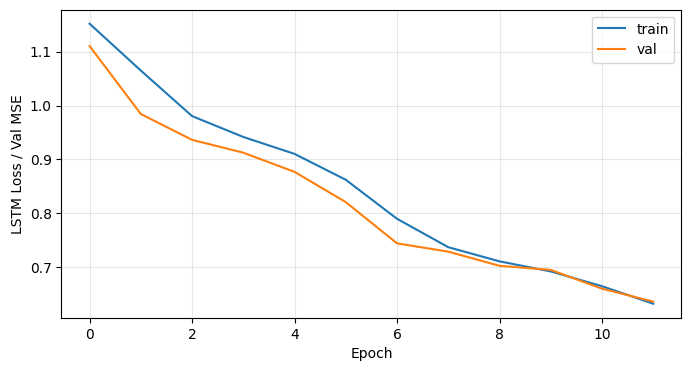

LSTM Test MSE (per value): 0.585536

--- Training Seq2Seq VAE ---
VAE Epoch 2/12 - TrainLoss: 1.1675 (Recon: 1.1667, KLD: 0.0073) ValLoss: 1.1452
VAE Epoch 4/12 - TrainLoss: 1.1334 (Recon: 1.0999, KLD: 0.3346) ValLoss: 1.1125
VAE Epoch 6/12 - TrainLoss: 1.0884 (Recon: 1.0248, KLD: 0.6362) ValLoss: 1.0999
VAE Epoch 8/12 - TrainLoss: 1.0875 (Recon: 1.0193, KLD: 0.6815) ValLoss: 1.0826
VAE Epoch 10/12 - TrainLoss: 1.0653 (Recon: 0.9859, KLD: 0.7945) ValLoss: 1.0609
VAE Epoch 12/12 - TrainLoss: 1.0433 (Recon: 0.9494, KLD: 0.9390) ValLoss: 1.0420


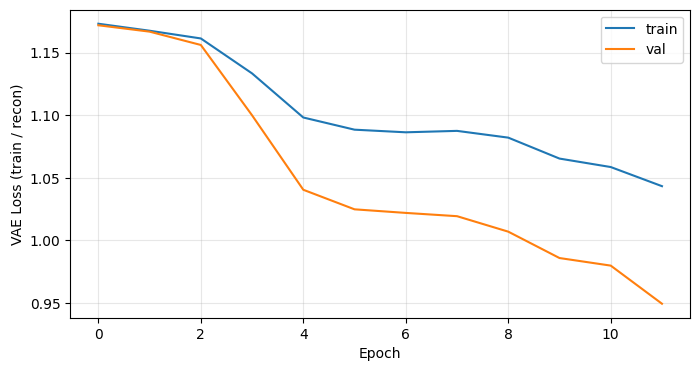


VAE Best-of-20 MSE: 0.558522
VAE Diversity (avg std): 0.239458
VAE Coverage (th=0.1): 0.1849
LSTM Test MSE (averaged per value): 0.585536

Visualizing examples (first 3):

Example 1 - LSTM vs VAE samples


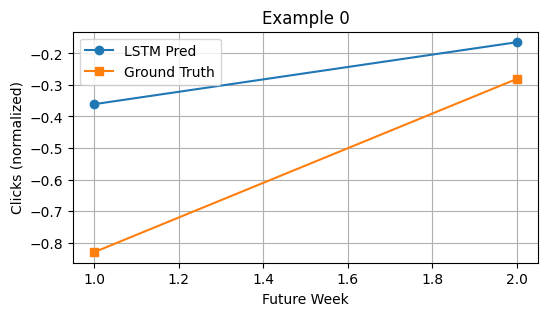

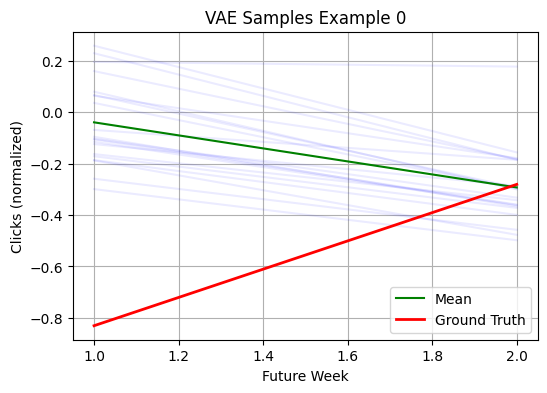


Example 2 - LSTM vs VAE samples


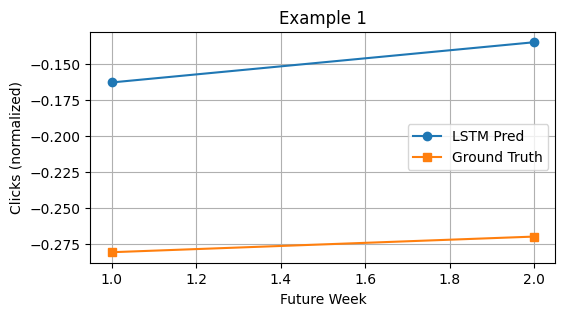

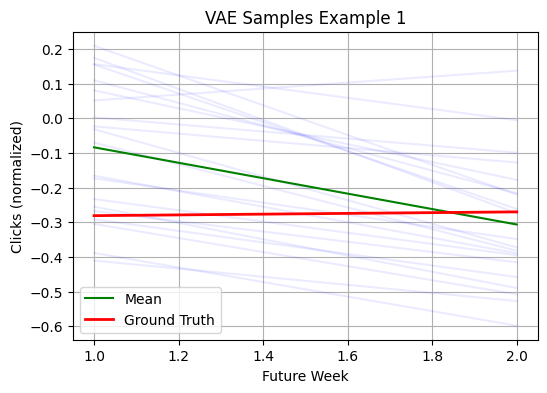


Example 3 - LSTM vs VAE samples


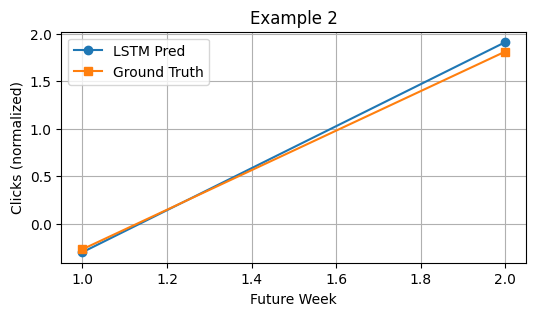

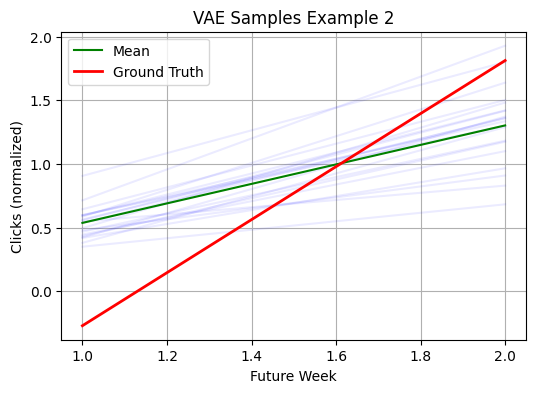


Models saved: seq2seq_lstm_oulad.pth, seq2seq_vae_oulad.pth

Done. Summary:
LSTM MSE: 0.585536
VAE Best-of-N MSE: 0.558522, Diversity: 0.239458, Coverage: 0.1849


In [6]:
# Seq2Seq LSTM vs Seq2Seq VAE - 完整 Colab/Local 可執行版本
# 符合作業 HW3 要求：同一程式檔包含
# - 資料讀取（若有 OULAD 三檔則讀取，否則自動產生模擬資料）
# - 特徵處理：clicks, submit_cnt/has_submit, avg_score_sofar, clicks_diff1
# - 以 student_id 切分 train/val/test（避免資料洩漏）
# - Seq2Seq LSTM（單一路徑預測未來 2 週） + Seq2Seq VAE（生成多樣化未來）
# - 訓練設定：batch_size=128, Adam lr=1e-3, seed=42
# - 評估指標：MSE (LSTM), Best-of-N MSE (VAE), Diversity, Coverage
# - 可視化函數
# 直接放到 Colab 執行即可（若要使用真實 OULAD ，上傳 studentInfo.csv/studentVle.csv/studentAssessment.csv）

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 固定隨機種子
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------
# 設備
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# 資料處理（支援讀取 OULAD 或自動產生模擬資料）
# ---------------------------
class DataHandler:
    def __init__(self, data_dir=None, min_weeks_needed=12):
        self.data_dir = data_dir
        self.min_weeks_needed = min_weeks_needed
        self.student_scalers = {}  # per-student scaler for feature normalization

    def load_oulad_or_synthetic(self):
        """嘗試讀取 OULAD 三檔，若不存在則回傳模擬資料"""
        if self.data_dir and all(os.path.exists(os.path.join(self.data_dir, fn)) for fn in
                                 ["studentInfo.csv", "studentVle.csv", "studentAssessment.csv"]):
            print("Loading OULAD files from", self.data_dir)
            si = pd.read_csv(os.path.join(self.data_dir, "studentInfo.csv"))
            sv = pd.read_csv(os.path.join(self.data_dir, "studentVle.csv"))
            sa = pd.read_csv(os.path.join(self.data_dir, "studentAssessment.csv"))
            # 期望欄位存在： id_student, date (week), sum_click (或類似)
            # 若欄位名不同，使用者需自行調整。這裡假定標準 OULAD 欄位名稱已存在或近似。
            # 轉換欄位名以配合後續程式
            # 假設 studentVle 有 id_student, date, sum_click (若沒有，使用 clicks 或 similar)
            # 假設 studentAssessment 有 id_student, date, score
            # 若無法直接使用，建議先在 Colab 中檢視 CSV 再執行
            return si, sv, sa
        else:
            print("OULAD files not found - creating synthetic dataset (structure matches).")
            return self.create_synthetic_data()

    def create_synthetic_data(self, n_students=1000, n_weeks=15):
        """產生模擬資料（與使用者最初程式類似，但確保多個學生會有足夠週數）"""
        np.random.seed(SEED)
        student_info = pd.DataFrame({
            "id_student": np.arange(1, n_students + 1),
            "code_module": np.random.choice(["AAA", "BBB", "CCC"], size=n_students),
            "code_presentation": np.random.choice(["2013B", "2014J", "2014B"], size=n_students)
        })
        student_vle_rows = []
        for sid in range(1, n_students + 1):
            # 隨機決定學生最早與最晚週數，確保部分學生滿足 min_weeks_needed
            start_week = np.random.randint(1, 4)
            # 確保大多數學生有至少 min_weeks_needed 週的資料
            end_week = start_week + np.random.randint(self.min_weeks_needed, n_weeks + 1)
            end_week = min(end_week, n_weeks)
            student_type = np.random.choice(['active', 'average', 'inactive'], p=[0.3, 0.5, 0.2])
            if student_type == 'active':
                base = np.random.poisson(25)
                trend = np.random.choice([0.15, 0.25, 0.35])
                noise = 2.0
            elif student_type == 'average':
                base = np.random.poisson(15)
                trend = np.random.choice([-0.05, 0.0, 0.05])
                noise = 3.0
            else:
                base = np.random.poisson(8)
                trend = np.random.choice([-0.2, -0.1])
                noise = 2.0
            for w in range(start_week, end_week + 1):
                clicks = max(0, base + trend * w + np.random.normal(0, noise))
                if w in [5, 10, 14]:
                    clicks *= 1.5
                student_vle_rows.append({"id_student": sid, "date": w, "sum_click": clicks})
        student_vle = pd.DataFrame(student_vle_rows)

        student_assessment_rows = []
        for sid in range(1, n_students + 1):
            n_assess = np.random.randint(3, 7)
            for _ in range(n_assess):
                week = np.random.randint(2, n_weeks - 1)
                if sid % 3 == 0:
                    score = np.random.normal(85, 8)
                elif sid % 3 == 1:
                    score = np.random.normal(70, 12)
                else:
                    score = np.random.normal(55, 15)
                score = float(max(0, min(100, score)))
                student_assessment_rows.append({"id_student": sid, "date": int(week), "score": score})
        student_assessment = pd.DataFrame(student_assessment_rows)

        return student_info, student_vle, student_assessment

    def preprocess_weekly(self, student_info, student_vle, student_assessment, target_seq_len=8, future_len=2):
        """
        以學生為單位產生每周序列：
        - features: clicks, submit_cnt (0/1), avg_score_sofar, clicks_diff1
        - 只保留具有足夠周數（>= min_weeks_needed）的學生
        - 返回合併的 weekly dataframe（包含 student_id, week, features...）
        """
        records = []
        for sid in tqdm(student_info['id_student'].unique(), desc="Preprocessing students"):
            s_clicks = student_vle[student_vle['id_student'] == sid].copy()
            if s_clicks.empty:
                continue
            min_w, max_w = int(s_clicks['date'].min()), int(s_clicks['date'].max())
            if (max_w - min_w + 1) < self.min_weeks_needed:
                continue
            # create continuous weeks window (we'll slide later when creating sequences)
            weeks = np.arange(min_w, max_w + 1)
            dfw = pd.DataFrame({"week": weeks})
            df_clicks = s_clicks.rename(columns={"date": "week", "sum_click": "clicks"})[['week', 'clicks']]
            df = dfw.merge(df_clicks, on='week', how='left').fillna(0)
            # assessments
            s_assess = student_assessment[student_assessment['id_student'] == sid]
            df['submit_cnt'] = 0
            df['avg_score_sofar'] = 0.0
            cumulative = 0.0
            cnt = 0
            for _, row in s_assess.iterrows():
                w = int(row['date'])
                if w in df['week'].values:
                    idx = df.index[df['week'] == w][0]
                    df.at[idx, 'submit_cnt'] = 1
                    cumulative += float(row['score'])
                    cnt += 1
                    df.at[idx, 'avg_score_sofar'] = cumulative / cnt
            df['clicks_diff1'] = df['clicks'].diff().fillna(0)
            df['student_id'] = sid
            records.append(df)
        if not records:
            raise ValueError("No students with sufficient weeks after preprocessing.")
        weekly = pd.concat(records, ignore_index=True)
        return weekly

    def create_sequences(self, weekly_df, seq_length=8, pred_length=2):
        """對每位學生用滑動窗口建立 (input_seq, output_seq)；每位學生用自己的 scaler 進行標準化"""
        seqs = []
        features = ['clicks', 'submit_cnt', 'avg_score_sofar', 'clicks_diff1']
        for sid in weekly_df['student_id'].unique():
            sd = weekly_df[weekly_df['student_id'] == sid].sort_values('week').reset_index(drop=True)
            if len(sd) < seq_length + pred_length:
                continue
            data = sd[features].values.astype(np.float32)
            # per-student scaler (fit on his whole available data)
            scaler = StandardScaler()
            try:
                data_scaled = scaler.fit_transform(data)
            except Exception:
                continue
            self.student_scalers[sid] = scaler
            n = len(sd)
            for i in range(0, n - seq_length - pred_length + 1):
                inp = data_scaled[i:i + seq_length]
                out = data_scaled[i + seq_length:i + seq_length + pred_length, 0]  # 預測 clicks（normalized）
                seqs.append({'input': inp.astype(np.float32), 'output': out.astype(np.float32), 'student_id': sid})
        print(f"Created {len(seqs)} sequences.")
        return seqs

# ---------------------------
# Dataset / DataLoader
# ---------------------------
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        s = self.sequences[idx]
        # input: (seq_len, features)
        # output: (pred_len,)
        return torch.tensor(s['input'], dtype=torch.float32), torch.tensor(s['output'], dtype=torch.float32)

# ---------------------------
# Seq2Seq LSTM (單一路徑預測)
# Encoder: LSTM -> hidden
# Decoder: 使用一個 LSTM cell step-by-step (或直接用線性從 hidden 解碼成 pred_len)
# 這裡我們實現一個簡單可靠的 decoder：將 encoder 最後 hidden 投影成 pred_len outputs
# ---------------------------
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim=4, enc_hidden=64, dec_hidden=64, num_layers=1, pred_len=2):
        super().__init__()
        self.input_dim = input_dim
        self.enc_hidden = enc_hidden
        self.dec_hidden = dec_hidden
        self.num_layers = num_layers
        self.pred_len = pred_len

        # Encoder
        self.encoder = nn.LSTM(input_dim, enc_hidden, num_layers=num_layers, batch_first=True, bidirectional=False)

        # Decoder: simple MLP that maps encoder final hidden to sequence of future clicks
        # 使用線性層輸出 pred_len 值（單一路徑）
        self.decoder_fc = nn.Sequential(
            nn.Linear(enc_hidden, dec_hidden),
            nn.ReLU(),
            nn.Linear(dec_hidden, pred_len)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.encoder(x)  # h_n: (num_layers, batch, hidden)
        # 使用最後一層 hidden
        h_last = h_n[-1]  # (batch, hidden)
        out = self.decoder_fc(h_last)  # (batch, pred_len)
        return out

# ---------------------------
# Seq2Seq VAE
# Encoder: Bi-LSTM -> mean & logvar
# Reparameterize -> z
# Decoder: take z and expand to pred_len steps, pass through small LSTM or MLP to get pred_len outputs
# ---------------------------
class Seq2SeqVAE(nn.Module):
    def __init__(self, input_dim=4, enc_hidden=64, latent_dim=16, dec_hidden=64, num_layers=1, pred_len=2, bidirectional=True):
        super().__init__()
        self.input_dim = input_dim
        self.enc_hidden = enc_hidden
        self.latent_dim = latent_dim
        self.dec_hidden = dec_hidden
        self.num_layers = num_layers
        self.pred_len = pred_len
        self.bidirectional = bidirectional

        # Encoder (bidirectional recommended)
        self.encoder = nn.LSTM(input_dim, enc_hidden, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)

        enc_output_dim = enc_hidden * (2 if bidirectional else 1)
        self.fc_mu = nn.Linear(enc_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_output_dim, latent_dim)

        # Decoder: take z and repeat timesteps, then pass through an LSTM and output linear
        self.decoder_lstm = nn.LSTM(latent_dim, dec_hidden, num_layers=1, batch_first=True)
        self.decoder_out = nn.Linear(dec_hidden, 1)  # predict clicks per step

    def encode(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.encoder(x)
        # if bidirectional, h_n has shape (num_layers*2, batch, hidden). We take last two layers if bi.
        if self.bidirectional:
            # Take last forward and last backward states from last layer
            # For simplicity, cat the last two layers:
            if self.num_layers >= 1:
                h_forward = h_n[-2]  # (batch, hidden)
                h_backward = h_n[-1]  # (batch, hidden)
                h = torch.cat([h_forward, h_backward], dim=1)  # (batch, hidden*2)
            else:
                h = h_n.view(h_n.size(1), -1)
        else:
            h = h_n[-1]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, pred_len=None):
        if pred_len is None:
            pred_len = self.pred_len
        # z: (batch, latent_dim)
        z_seq = z.unsqueeze(1).repeat(1, pred_len, 1)  # (batch, pred_len, latent_dim)
        dec_out, _ = self.decoder_lstm(z_seq)  # (batch, pred_len, dec_hidden)
        out = self.decoder_out(dec_out).squeeze(-1)  # (batch, pred_len)
        return out

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, self.pred_len)
        return recon, mu, logvar

# ---------------------------
# 損失與訓練/驗證函數
# ---------------------------
def kld_loss_from_mu_logvar(mu, logvar):
    # KLD per batch (sum over latent dims, average over batch)
    # KLD = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # (batch,)
    return torch.mean(kld)  # scalar

def train_lstm_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    mse_criterion = nn.MSELoss()
    for X, y in loader:
        X = X.to(device)  # (B, seq_len, feat)
        y = y.to(device)  # (B, pred_len)
        optimizer.zero_grad()
        pred = model(X)  # (B, pred_len)
        loss = mse_criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def eval_lstm(model, loader, device):
    model.eval()
    mse_criterion = nn.MSELoss(reduction='sum')
    total_loss = 0.0
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device); y = y.to(device)
            pred = model(X)
            total_loss += mse_criterion(pred, y).item()
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    mse = total_loss / (len(loader.dataset) * loader.dataset[0][1].shape[0])  # per-value MSE
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    return mse, preds, targets

def train_vae_epoch(model, loader, optimizer, device, beta=0.1):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kld = 0.0
    mse_criterion = nn.MSELoss(reduction='mean')
    for X, y in loader:
        X = X.to(device); y = y.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(X)  # recon: (B, pred_len)
        recon_loss = mse_criterion(recon, y)  # mean over batch & pred_len
        kld = kld_loss_from_mu_logvar(mu, logvar)  # mean over batch
        loss = recon_loss + beta * kld
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        total_recon += recon_loss.item() * X.size(0)
        total_kld += kld.item() * X.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kld / n

def eval_vae(model, loader, device, num_samples=20):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            batch_preds = []
            # For each sample in batch, generate num_samples reconstructions
            for s in range(num_samples):
                recon, _, _ = model(X)  # (B, pred_len)
                batch_preds.append(recon.cpu().numpy())  # list of (B, pred_len)
            # stack -> (num_samples, B, pred_len)
            batch_preds = np.stack(batch_preds, axis=0)
            # transpose to (B, num_samples, pred_len)
            batch_preds = np.transpose(batch_preds, (1, 0, 2))
            all_preds.append(batch_preds)
            all_targets.append(y.numpy())
    all_preds = np.concatenate(all_preds, axis=0)  # (N, num_samples, pred_len)
    all_targets = np.concatenate(all_targets, axis=0)  # (N, pred_len)
    return all_preds, all_targets

# ---------------------------
# 評估指標（Best-of-N MSE、Diversity、Coverage）
# ---------------------------
def best_of_n_mse(predictions, targets, n=None):
    # predictions: (N, num_samples, pred_len)
    # targets: (N, pred_len)
    if n is None:
        n = predictions.shape[1]
    N = predictions.shape[0]
    mses = []
    for i in range(N):
        sample_mses = np.mean((predictions[i, :n, :] - targets[i]) ** 2, axis=1)  # (num_samples,)
        mses.append(np.min(sample_mses))
    return float(np.mean(mses))

def diversity_metric(predictions):
    # diversity: average std across samples per example and per timestep, then mean
    # predictions: (N, num_samples, pred_len)
    per_example_std = np.std(predictions, axis=1)  # (N, pred_len)
    return float(np.mean(per_example_std))

def coverage_metric(predictions, targets, threshold=0.1):
    # coverage: proportion where target is within [min(pred)-thresh, max(pred)+thresh] for all timesteps
    N = predictions.shape[0]
    covered = 0
    for i in range(N):
        pred_min = np.min(predictions[i], axis=0)
        pred_max = np.max(predictions[i], axis=0)
        tgt = targets[i]
        if np.all((tgt >= pred_min - threshold) & (tgt <= pred_max + threshold)):
            covered += 1
    return covered / N

# ---------------------------
# 可視化工具
# ---------------------------
def plot_training_curves(train_vals, val_vals, title="Loss"):
    plt.figure(figsize=(8,4))
    plt.plot(train_vals, label='train')
    plt.plot(val_vals, label='val')
    plt.xlabel('Epoch')
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_example_predictions_lstm(preds, targets, idx=0):
    # preds: (N, pred_len), targets: (N, pred_len)
    p = preds[idx]
    t = targets[idx]
    x = np.arange(1, len(p)+1)
    plt.figure(figsize=(6,3))
    plt.plot(x, p, '-o', label='LSTM Pred')
    plt.plot(x, t, '-s', label='Ground Truth')
    plt.xlabel('Future Week')
    plt.ylabel('Clicks (normalized)')
    plt.title(f"Example {idx}")
    plt.legend(); plt.grid(True); plt.show()

def plot_example_predictions_vae(predictions, targets, idx=0, plot_n=20):
    # predictions: (N, num_samples, pred_len)
    preds = predictions[idx][:plot_n]  # (plot_n, pred_len)
    t = targets[idx]
    x = np.arange(1, preds.shape[1]+1)
    plt.figure(figsize=(6,4))
    for s in range(preds.shape[0]):
        plt.plot(x, preds[s], color='blue', alpha=0.08)
    plt.plot(x, np.mean(preds, axis=0), color='green', label='Mean')
    plt.plot(x, t, color='red', linewidth=2, label='Ground Truth')
    plt.xlabel('Future Week'); plt.ylabel('Clicks (normalized)')
    plt.title(f"VAE Samples Example {idx}")
    plt.legend(); plt.grid(True); plt.show()

# ---------------------------
# 主流程
# ---------------------------
def main_flow(data_dir=None,
              seq_len=8,
              pred_len=2,
              batch_size=128,
              lstm_hidden=64,
              vae_enc_hidden=64,
              vae_latent=16,
              epochs=10,
              beta=0.1,
              vae_num_samples=20):
    dh = DataHandler(data_dir=data_dir, min_weeks_needed=12)
    student_info, student_vle, student_assessment = dh.load_oulad_or_synthetic()

    weekly = dh.preprocess_weekly(student_info, student_vle, student_assessment)
    print("Weekly data rows:", len(weekly))
    print("Students:", weekly['student_id'].nunique())

    sequences = dh.create_sequences(weekly, seq_length=seq_len, pred_length=pred_len)
    if len(sequences) == 0:
        raise ValueError("No sequences created. Check data or parameters.")

    # split by student id
    student_ids = sorted(list({s['student_id'] for s in sequences}))
    train_ids, temp_ids = train_test_split(student_ids, test_size=0.3, random_state=SEED)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=SEED)

    train_seq = [s for s in sequences if s['student_id'] in train_ids]
    val_seq = [s for s in sequences if s['student_id'] in val_ids]
    test_seq = [s for s in sequences if s['student_id'] in test_ids]

    print(f"Train seq: {len(train_seq)}, Val seq: {len(val_seq)}, Test seq: {len(test_seq)}")

    train_loader = DataLoader(SequenceDataset(train_seq), batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(SequenceDataset(val_seq), batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(SequenceDataset(test_seq), batch_size=batch_size, shuffle=False, drop_last=False)

    # ---------------------------
    # Train Seq2Seq LSTM
    # ---------------------------
    print("\n--- Training Seq2Seq LSTM ---")
    lstm_model = Seq2SeqLSTM(input_dim=4, enc_hidden=lstm_hidden, dec_hidden=lstm_hidden, num_layers=1, pred_len=pred_len).to(device)
    lstm_opt = optim.Adam(lstm_model.parameters(), lr=1e-3)
    lstm_train_losses = []
    lstm_val_losses = []

    for ep in range(epochs):
        train_loss = train_lstm_epoch(lstm_model, train_loader, lstm_opt, device)
        val_mse, _, _ = eval_lstm(lstm_model, val_loader, device)
        lstm_train_losses.append(train_loss)
        lstm_val_losses.append(val_mse)
        if (ep+1) % max(1, epochs//5) == 0:
            print(f"LSTM Epoch {ep+1}/{epochs} - TrainLoss: {train_loss:.4f}, ValMSE: {val_mse:.4f}")

    plot_training_curves(lstm_train_losses, lstm_val_losses, title="LSTM Loss / Val MSE")

    lstm_test_mse, lstm_preds, lstm_targets = eval_lstm(lstm_model, test_loader, device)
    print(f"LSTM Test MSE (per value): {lstm_test_mse:.6f}")

    # ---------------------------
    # Train Seq2Seq VAE
    # ---------------------------
    print("\n--- Training Seq2Seq VAE ---")
    vae_model = Seq2SeqVAE(input_dim=4, enc_hidden=vae_enc_hidden, latent_dim=vae_latent, dec_hidden=vae_enc_hidden, num_layers=1, pred_len=pred_len).to(device)
    vae_opt = optim.Adam(vae_model.parameters(), lr=1e-3)
    vae_train_losses = []
    vae_val_losses = []
    vae_recon_losses = []
    vae_kld_losses = []

    for ep in range(epochs):
        t_loss, t_recon, t_kld = train_vae_epoch(vae_model, train_loader, vae_opt, device, beta=beta)
        # For validation we compute recon + beta*kld approx by running forward and computing components
        vae_model.eval()
        val_recon = 0.0
        val_kld = 0.0
        n_val = 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv = Xv.to(device); yv = yv.to(device)
                recon, mu, logvar = vae_model(Xv)
                val_recon += nn.MSELoss(reduction='mean')(recon, yv).item() * Xv.size(0)
                val_kld += kld_loss_from_mu_logvar(mu, logvar).item() * Xv.size(0)
                n_val += Xv.size(0)
        if n_val > 0:
            val_recon /= n_val
            val_kld /= n_val
            val_loss = val_recon + beta * val_kld
        else:
            val_loss = None
        vae_train_losses.append(t_loss)
        vae_recon_losses.append(t_recon)
        vae_kld_losses.append(t_kld)
        if (ep+1) % max(1, epochs//5) == 0:
            print(f"VAE Epoch {ep+1}/{epochs} - TrainLoss: {t_loss:.4f} (Recon: {t_recon:.4f}, KLD: {t_kld:.4f}) ValLoss: {val_loss:.4f}")

    plot_training_curves(vae_train_losses, [l if l is not None else 0 for l in vae_recon_losses], title="VAE Loss (train / recon)")

    # ---------------------------
    # VAE Evaluation (generate multiple samples)
    # ---------------------------
    vae_preds, vae_tgts = eval_vae(vae_model, test_loader, device, num_samples=vae_num_samples)
    # vae_preds: (N, num_samples, pred_len), vae_tgts: (N, pred_len)
    bo_n = best_of_n_mse(vae_preds, vae_tgts, n=vae_num_samples)
    div = diversity_metric(vae_preds)
    cov = coverage_metric(vae_preds, vae_tgts, threshold=0.1)
    print(f"\nVAE Best-of-{vae_num_samples} MSE: {bo_n:.6f}")
    print(f"VAE Diversity (avg std): {div:.6f}")
    print(f"VAE Coverage (th=0.1): {cov:.4f}")

    # ---------------------------
    # LSTM final single-path evaluation (on test set)
    # ---------------------------
    # lstm_preds (N, pred_len) and lstm_targets (N, pred_len) already computed
    # compute MSE per-sample then mean
    lstm_value_mse = np.mean((lstm_preds - lstm_targets) ** 2)
    print(f"LSTM Test MSE (averaged per value): {lstm_value_mse:.6f}")

    # ---------------------------
    # 顯示與可視化幾個範例
    # ---------------------------
    print("\nVisualizing examples (first 3):")
    for idx in range(min(3, len(lstm_preds))):
        print(f"\nExample {idx+1} - LSTM vs VAE samples")
        plot_example_predictions_lstm(lstm_preds, lstm_targets, idx=idx)
        plot_example_predictions_vae(vae_preds, vae_tgts, idx=idx, plot_n=min(30, vae_num_samples))

    # ---------------------------
    # 儲存模型（選擇性）
    # ---------------------------
    torch.save(lstm_model.state_dict(), "seq2seq_lstm_oulad.pth")
    torch.save(vae_model.state_dict(), "seq2seq_vae_oulad.pth")
    print("\nModels saved: seq2seq_lstm_oulad.pth, seq2seq_vae_oulad.pth")

    # 返回評估值以便進一步分析
    results = {
        "lstm_test_mse": lstm_value_mse,
        "vae_best_of_n_mse": bo_n,
        "vae_diversity": div,
        "vae_coverage": cov,
        "lstm_preds": lstm_preds,
        "lstm_targets": lstm_targets,
        "vae_preds": vae_preds,
        "vae_targets": vae_tgts
    }
    return results

# ---------------------------
# 執行（在 Colab 或本地直接呼叫 main_flow()）
# ---------------------------
if __name__ == "__main__":
    # 若您在 Colab 上並已上傳 OULAD 檔案，可傳入 data_dir='/content' 或該檔案路徑
    results = main_flow(
        data_dir=None,     # 若要用真實檔案：指定包含 studentInfo.csv 等檔的資料夾
        seq_len=8,
        pred_len=2,
        batch_size=128,
        lstm_hidden=64,
        vae_enc_hidden=64,
        vae_latent=16,
        epochs=12,         # 建議最少 5，實驗可提升到 20~30
        beta=0.1,
        vae_num_samples=20
    )
    print("\nDone. Summary:")
    print(f"LSTM MSE: {results['lstm_test_mse']:.6f}")
    print(f"VAE Best-of-N MSE: {results['vae_best_of_n_mse']:.6f}, Diversity: {results['vae_diversity']:.6f}, Coverage: {results['vae_coverage']:.4f}")
